In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [2]:
df=pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [5]:
df.isnull().count

<bound method DataFrame.count of     Weight  Height
0    False   False
1    False   False
2    False   False
3    False   False
4    False   False
5    False   False
6    False   False
7    False   False
8    False   False
9    False   False
10   False   False
11   False   False
12   False   False
13   False   False
14   False   False
15   False   False
16   False   False
17   False   False
18   False   False
19   False   False
20   False   False
21   False   False
22   False   False>

Text(0.5, 1.0, 'Data_Representation')

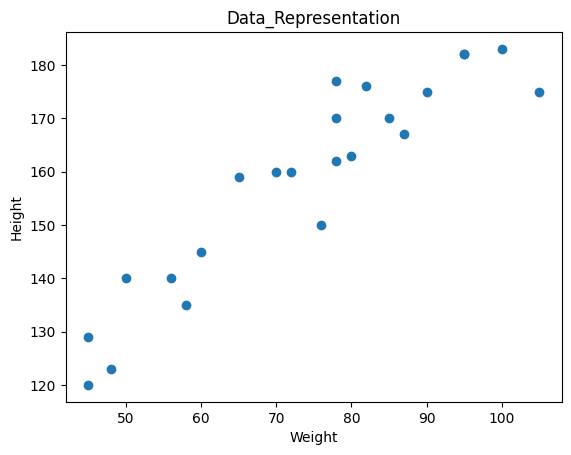

In [ ]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Data_Representation")

In [13]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


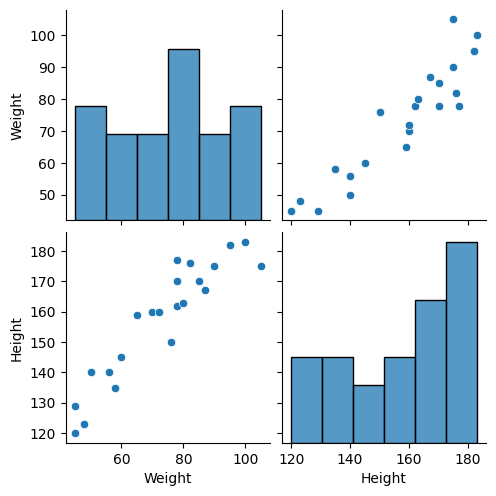

In [15]:
sns.pairplot(df)

In [17]:
#split the data
x=df[['Weight']]
y=df['Height']

In [21]:
print(x.shape,y.shape)

(23, 1) (23,)


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler=StandardScaler()

In [29]:
x_train=scaler.fit_transform(x_train)

In [30]:
x_test=scaler.transform(x_test)

In [31]:
x_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [32]:
from sklearn.linear_model import LinearRegression

In [40]:
regression=LinearRegression(n_jobs=-1)

In [41]:
regression.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [42]:
print(regression.coef_)
print(regression.fit_intercept)
print(regression.intercept_)

[17.2982057]
True
156.47058823529412


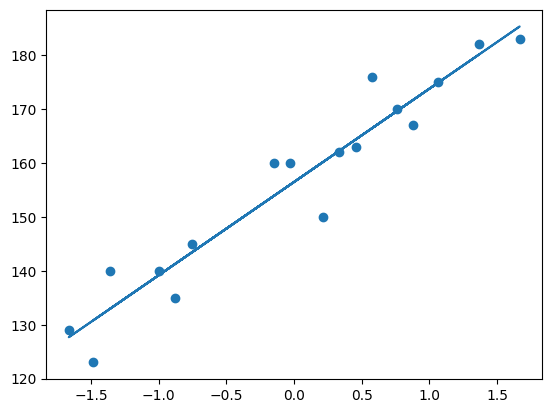

In [44]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train))

In [ ]:
#tranning data
regression.predict(scaler.transform([[105]]))

C:\Users\sonu\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([190.55897293])

prediction of test data
y=mx+b
m=17.2982057(x_test)+156.47058823529412

In [48]:
y_pred=regression.predict(x_test)

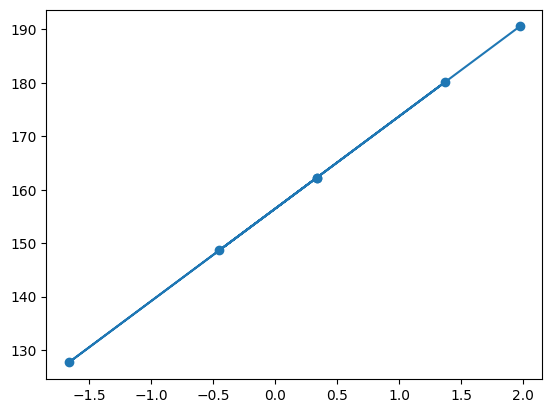

In [52]:
plt.scatter(x_test,y_pred)
plt.plot(x_test,regression.predict(x_test))

In [53]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [56]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rsme=np.sqrt(mse)

In [63]:
print(mse,mae,rsme)

114.84069295228699 9.66512588679501 10.716374991212605


In [64]:
regression.predict(scaler.transform([[50]]))

C:\Users\sonu\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([132.92309646])

In [65]:
print(regression.score(x_train,y_train))

0.9208287444697435
